# Phase 2: Decision Tree and Random Forest
## Step 1: Modeling Environment Setup & Invariants Verification

### Purpose & Methodology Plan
This notebook establishes the leak-free modeling foundation for evaluating **Decision Tree** and **Random Forest** classifiers on the movie review emotion classification dataset. To ensure valid, publication-grade results, the modeling pipeline follows strict methodological standards:
1. **Grouped Stratified Cross-Validation**: Because individual movie reviews share stylistic and thematic properties by movie, all cross-validation is grouped by `movie_name` using `StratifiedGroupKFold` ($k=5$). This prevents reviews from the same film appearing in both training and validation folds.
2. **Evaluation Metric**: Due to significant class imbalance across the 7 emotion categories, **Macro F1-score** serves as the primary optimization and comparison metric, alongside Accuracy and Weighted F1.
3. **Pipeline Encapsulation**: All preprocessing stages (TF-IDF vectorization, genre multi-hot encoding, IQR outlier capping, RobustScaler, and MinMaxScaler) are encapsulated inside scikit-learn `Pipeline` objects and fit strictly on training splits/folds to eliminate data leakage.

*Note: This setup step executes data loading, splitting, grouped CV smoke testing, preprocessor verification, and baseline calculation without training or tuning any classifiers.*

### 1. Imports and Reproducibility Constants
Initialize random seeds, configure execution paths to import modular project utilities from `src/`, and define global constants.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score

# Reproducibility constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
N_SPLITS = 5

# Ensure repository root is in sys.path when running from notebooks/
current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_prep import find_repo_root, get_cv, load_clean, make_split
from src.preprocessors import build_full_preprocessor

REPO_ROOT = find_repo_root()

# Helper to print paths relative to REPO_ROOT without exposing machine-specific absolute paths
def rel(p):
    try:
        return str(Path(p).resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return Path(p).name

print(f"Repository Root : {REPO_ROOT.name}")
print(f"RANDOM_STATE    : {RANDOM_STATE}")
print(f"N_SPLITS (CV)   : {N_SPLITS}")


Repository Root : AI:ML Project
RANDOM_STATE    : 42
N_SPLITS (CV)   : 5


### 2. Load Clean Dataset and Validate Invariants
Load the preprocessed dataset via `load_clean()` and verify that row counts, movie counts, and class constraints strictly match project specifications.

In [2]:
df = load_clean()

n_rows = len(df)
n_movies = df["movie_name"].nunique()
class_counts = df["emotion"].value_counts()
class_pcts = df["emotion"].value_counts(normalize=True) * 100

print("=== Dataset Summary ===")
print(f"Total Rows    : {n_rows:,}")
print(f"Unique Movies : {n_movies:,}")
print(f"Target Classes: {len(class_counts)}\n")
print("Class Distribution:")
for cls, count in class_counts.items():
    pct = class_pcts[cls]
    print(f"  {cls:<10}: {count:5d} ({pct:5.2f}%)")

# Assertions
assert n_rows == 16107, f"Expected 16,107 rows, got {n_rows}"
assert n_movies == 1309, f"Expected 1,309 movies, got {n_movies}"
assert len(class_counts) == 7, f"Expected 7 classes, got {len(class_counts)}"
assert "surprise" not in df["emotion"].values, "Found 'surprise' in emotion column"
print("\n✔ Dataset invariants verified: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped).")

=== Dataset Summary ===
Total Rows    : 16,107
Unique Movies : 1,309
Target Classes: 7

Class Distribution:
  sadness   :  6555 (40.70%)
  joy       :  2765 (17.17%)
  anticipation:  2166 (13.45%)
  optimism  :  1772 (11.00%)
  fear      :  1386 ( 8.60%)
  anger     :   929 ( 5.77%)
  disgust   :   534 ( 3.32%)

✔ Dataset invariants verified: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped).


### 3. Stratified Grouped Train/Test Split
Split the dataset using `make_split()` ($80/20$ ratio, grouped by `movie_name`, stratified by `emotion`). Verify zero movie and text overlap between splits.

In [3]:
train_df, test_df = make_split(df, test_size=0.2, random_state=RANDOM_STATE)

train_rows = len(train_df)
test_rows = len(test_df)
train_movies = set(train_df["movie_name"].unique())
test_movies = set(test_df["movie_name"].unique())
movie_overlap = len(train_movies.intersection(test_movies))

train_texts = set(train_df["cleaned_review"].unique())
test_texts = set(test_df["cleaned_review"].unique())
text_overlap = len(train_texts.intersection(test_texts))

print("=== Split Summary ===")
print(f"Train Rows   : {train_rows:,} ({train_rows/len(df)*100:.2f}%)")
print(f"Test Rows    : {test_rows:,} ({test_rows/len(df)*100:.2f}%)")
print(f"Train Movies : {len(train_movies):,}")
print(f"Test Movies  : {len(test_movies):,}")
print(f"Movie Overlap: {movie_overlap}")
print(f"Text Overlap : {text_overlap}")

assert train_rows == 12886, f"Expected 12,886 train rows, got {train_rows}"
assert test_rows == 3221, f"Expected 3,221 test rows, got {test_rows}"
assert movie_overlap == 0, f"Expected 0 movie overlap, found {movie_overlap}"
assert text_overlap == 0, f"Expected 0 text overlap, found {text_overlap}"
print("\n✔ Split invariants verified: 12,886 train / 3,221 test rows, ZERO movie overlap, ZERO text overlap.")

=== Split Summary ===
Train Rows   : 12,886 (80.00%)
Test Rows    : 3,221 (20.00%)
Train Movies : 1,048
Test Movies  : 261
Movie Overlap: 0
Text Overlap : 0

✔ Split invariants verified: 12,886 train / 3,221 test rows, ZERO movie overlap, ZERO text overlap.


### 4. Targets, Features, and Groups Extraction
Separate feature DataFrames, target series, and movie group identifiers.

> **Important Note:** In all subsequent model training steps, `groups_train` must be explicitly passed to `GridSearchCV.fit()` and `cross_val_score()` (`groups=groups_train`) to ensure grouped cross-validation without leakage.

In [4]:
X_train = train_df
y_train = train_df["emotion"]
groups_train = train_df["movie_name"]

X_test = test_df
y_test = test_df["emotion"]
groups_test = test_df["movie_name"]

# Fixed canonical ordering of target labels
LABELS = sorted(y_train.unique().tolist())

# Compare train vs test class distributions side-by-side
dist_df = pd.DataFrame({
    "Train Count": y_train.value_counts()[LABELS],
    "Train %": (y_train.value_counts(normalize=True)[LABELS] * 100).round(2),
    "Test Count": y_test.value_counts()[LABELS],
    "Test %": (y_test.value_counts(normalize=True)[LABELS] * 100).round(2),
})

print("=== Class Distribution Comparison ===")
print(dist_df.to_string())
print(f"\nCanonical Target Labels ({len(LABELS)}): {LABELS}")

=== Class Distribution Comparison ===
              Train Count  Train %  Test Count  Test %
emotion                                               
anger                 744     5.77         185    5.74
anticipation         1733    13.45         433   13.44
disgust               427     3.31         107    3.32
fear                 1109     8.61         277    8.60
joy                  2212    17.17         553   17.17
optimism             1417    11.00         355   11.02
sadness              5244    40.70        1311   40.70

Canonical Target Labels (7): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']


### 5. Preprocessor Architecture (Unfitted)
Instantiate the modular `ColumnTransformer` via `build_full_preprocessor(use_svd=False)`.

> **Methodology Note:** The preprocessor is left **unfitted**. It will serve as the initial stage in every scikit-learn `Pipeline`, ensuring that stateful parameters (TF-IDF vocabulary/IDF, outlier fences, scalers) are fit solely on training folds during cross-validation.

In [5]:
preprocessor = build_full_preprocessor(use_svd=False)

print("=== Preprocessor (ColumnTransformer) Structure ===")
for name, transformer, columns in preprocessor.transformers:
    step_names = [s[0] for s in transformer.steps]
    print(f"• Branch '{name}':")
    print(f"    Target Column(s) : {columns}")
    print(f"    Pipeline Steps   : {' -> '.join(step_names)}")
    print(f"    Transformer Type : {transformer.__class__.__name__}")

=== Preprocessor (ColumnTransformer) Structure ===
• Branch 'text_features':
    Target Column(s) : Reviews
    Pipeline Steps   : cleaner -> stopword_filter -> tfidf
    Transformer Type : Pipeline
• Branch 'genre_features':
    Target Column(s) : genres
    Pipeline Steps   : binarizer
    Transformer Type : Pipeline
• Branch 'word_count_features':
    Target Column(s) : Reviews
    Pipeline Steps   : cleaner -> wc_extractor -> capper -> scaler
    Transformer Type : Pipeline
• Branch 'rating_features':
    Target Column(s) : ['Ratings']
    Pipeline Steps   : scaler
    Transformer Type : Pipeline


### 6. Smoke Test: Grouped Cross-Validation (No Model)
Verify the grouped stratified cross-validation splitter (`StratifiedGroupKFold`) over 5 folds without model fitting. Confirm that no movie spans across training and validation partitions.

In [6]:
cv = get_cv(n_splits=N_SPLITS)

print(f"=== {N_SPLITS}-Fold StratifiedGroupKFold Validation Smoke Test ===")
fold_records = []

for fold, (trn_idx, val_idx) in enumerate(cv.split(X_train, y_train, groups=groups_train), start=1):
    fold_train_movies = set(X_train.iloc[trn_idx]["movie_name"].unique())
    fold_val_movies = set(X_train.iloc[val_idx]["movie_name"].unique())
    overlap = len(fold_train_movies.intersection(fold_val_movies))
    
    assert overlap == 0, f"Fold {fold} movie overlap detected: {overlap}"
    
    val_counts = y_train.iloc[val_idx].value_counts().to_dict()
    for lbl in LABELS:
        cnt = val_counts.get(lbl, 0)
        if cnt < 30:
            print(f"  [WARNING] Fold {fold} class '{lbl}' has fewer than 30 validation samples ({cnt})")
            
    rec = {
        "Fold": fold,
        "Train Rows": len(trn_idx),
        "Val Rows": len(val_idx),
        "Val Movies": len(fold_val_movies),
        "Movie Overlap": overlap
    }
    for lbl in LABELS:
        rec[lbl] = val_counts.get(lbl, 0)
    fold_records.append(rec)

fold_summary_df = pd.DataFrame(fold_records)
print("\nFold Breakdown Table:")
print(fold_summary_df.to_string(index=False))
print("\n✔ CV smoke test passed: exactly 0 movie overlap across all 5 folds.")

=== 5-Fold StratifiedGroupKFold Validation Smoke Test ===



Fold Breakdown Table:
 Fold  Train Rows  Val Rows  Val Movies  Movie Overlap  anger  anticipation  disgust  fear  joy  optimism  sadness
    1       10308      2578         209              0    148           346       87   222  443       283     1049
    2       10309      2577         209              0    149           346       84   222  443       284     1049
    3       10309      2577         210              0    149           347       86   222  442       283     1048
    4       10309      2577         210              0    149           347       85   221  442       284     1049
    5       10309      2577         210              0    149           347       85   222  442       283     1049

✔ CV smoke test passed: exactly 0 movie overlap across all 5 folds.


### 7. Smoke Test: Preprocessor Transformation Verification (No Model)
Test feature generation using a clone of `preprocessor` fit only on `X_train` and evaluated on `X_test`. Verify feature dimensions, non-zero sparsity counts, and the absence of NaN/Inf values.

In [7]:
import scipy.sparse as sp

# Fit CLONE of preprocessor strictly on X_train to test feature extraction
preprocessor_clone = clone(preprocessor)
X_train_trans = preprocessor_clone.fit_transform(X_train)
X_test_trans = preprocessor_clone.transform(X_test)

train_shape = X_train_trans.shape
test_shape = X_test_trans.shape

train_nnz = X_train_trans.nnz if sp.issparse(X_train_trans) else np.count_nonzero(X_train_trans)
test_nnz = X_test_trans.nnz if sp.issparse(X_test_trans) else np.count_nonzero(X_test_trans)

has_nan = np.isnan(X_train_trans.data).any() if sp.issparse(X_train_trans) else np.isnan(X_train_trans).any()
has_inf = np.isinf(X_train_trans.data).any() if sp.issparse(X_train_trans) else np.isinf(X_train_trans).any()

print("=== Preprocessor Transformation Verification ===")
print(f"X_train Transformed Shape : {train_shape}")
print(f"X_test Transformed Shape  : {test_shape}")
print(f"Train Non-Zero Elements   : {train_nnz:,}")
print(f"Test Non-Zero Elements    : {test_nnz:,}")
print(f"Contains NaN Values       : {has_nan}")
print(f"Contains Inf Values       : {has_inf}")

assert train_shape[1] == test_shape[1], f"Feature count mismatch: train {train_shape[1]} vs test {test_shape[1]}"
assert not has_nan, "Found NaN values in transformed features"
assert not has_inf, "Found Inf values in transformed features"

# Extract dynamic feature counts per branch before discarding clone
n_text = len(preprocessor_clone.named_transformers_["text_features"].named_steps["tfidf"].vocabulary_)
genre_step = preprocessor_clone.named_transformers_["genre_features"].named_steps["binarizer"]
n_genre = len(genre_step.genres_)
n_word = 1
n_rating = 1
n_total = train_shape[1]

FEATURE_INFO = {
    "total": n_total,
    "text": n_text,
    "genre": n_genre,
    "word_count": n_word,
    "rating": n_rating,
}
assert n_total == n_text + n_genre + n_word + n_rating, "Branch feature count sum does not match total columns"

# Discard temporary clone to maintain pristine state
del preprocessor_clone, X_train_trans, X_test_trans
print()
print("✔ Preprocessor smoke test passed (clone discarded; unfitted preprocessor preserved).")


=== Preprocessor Transformation Verification ===
X_train Transformed Shape : (12886, 2522)
X_test Transformed Shape  : (3221, 2522)
Train Non-Zero Elements   : 812,263
Test Non-Zero Elements    : 204,632
Contains NaN Values       : False
Contains Inf Values       : False

✔ Preprocessor smoke test passed (clone discarded; unfitted preprocessor preserved).


### 8. Majority-Class Baseline Performance (No Model Fitting)
Compute the baseline performance of a naive heuristic that always predicts the training set majority class on the test set.

In [8]:
majority_class = y_train.value_counts().idxmax()
majority_count = y_train.value_counts().max()
majority_pct = (majority_count / len(y_train)) * 100

# Predict majority class on test set
y_pred_majority = np.full(shape=len(y_test), fill_value=majority_class)
baseline_acc = accuracy_score(y_test, y_pred_majority)
baseline_macro_f1 = f1_score(y_test, y_pred_majority, labels=LABELS, average="macro", zero_division=0)
baseline_weighted_f1 = f1_score(y_test, y_pred_majority, labels=LABELS, average="weighted", zero_division=0)

BASELINE = {
    "majority_class": majority_class,
    "train_majority_count": int(majority_count),
    "train_majority_pct": float(majority_pct),
    "test_accuracy": float(baseline_acc),
    "test_macro_f1": float(baseline_macro_f1),
    "test_weighted_f1": float(baseline_weighted_f1),
}

print("=== Majority-Class Baseline Performance ===")
print(f"Majority Class (Train)     : '{majority_class}' ({majority_count:,} reviews, {majority_pct:.2f}%)")
print(f"Baseline Test Accuracy     : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Baseline Test Macro F1     : {baseline_macro_f1:.4f}")
print(f"Baseline Test Weighted F1  : {baseline_weighted_f1:.4f}")

=== Majority-Class Baseline Performance ===
Majority Class (Train)     : 'sadness' (5,244 reviews, 40.70%)
Baseline Test Accuracy     : 0.4070 (40.70%)
Baseline Test Macro F1     : 0.0827
Baseline Test Weighted F1  : 0.2355


### Chance-Level Baselines
While the majority-class baseline achieves 40.70% accuracy, its macro-F1 score is near zero (0.0827) by construction because it assigns zero predictions to six of the seven emotion classes. This makes it an artificially weak benchmark for macro-F1 comparison. Guessing at random according to training class proportions (stratified random) provides a fairer reference for imbalanced multi-class evaluation, while uniform random guessing serves as the theoretical uninformative lower bound.

In [9]:
from sklearn.dummy import DummyClassifier

# Placeholder feature matrices for dummy estimators (features do not affect dummy predictions)
X_dummy_train = np.zeros((len(y_train), 1))
X_dummy_test = np.zeros((len(y_test), 1))

strat_accs = []
strat_f1s = []
unif_accs = []
unif_f1s = []

for seed in range(200):
    # Stratified random guessing according to training class proportions
    clf_strat = DummyClassifier(strategy="stratified", random_state=seed)
    clf_strat.fit(X_dummy_train, y_train)
    y_pred_strat = clf_strat.predict(X_dummy_test)
    strat_accs.append(accuracy_score(y_test, y_pred_strat))
    strat_f1s.append(f1_score(y_test, y_pred_strat, labels=LABELS, average="macro", zero_division=0))
    
    # Uniform random guessing across all 7 classes
    clf_unif = DummyClassifier(strategy="uniform", random_state=seed)
    clf_unif.fit(X_dummy_train, y_train)
    y_pred_unif = clf_unif.predict(X_dummy_test)
    unif_accs.append(accuracy_score(y_test, y_pred_unif))
    unif_f1s.append(f1_score(y_test, y_pred_unif, labels=LABELS, average="macro", zero_division=0))

BASELINE["stratified_random"] = {
    "accuracy_mean": float(np.mean(strat_accs)),
    "accuracy_std": float(np.std(strat_accs)),
    "macro_f1_mean": float(np.mean(strat_f1s)),
    "macro_f1_std": float(np.std(strat_f1s)),
}

BASELINE["uniform_random"] = {
    "accuracy_mean": float(np.mean(unif_accs)),
    "accuracy_std": float(np.std(unif_accs)),
    "macro_f1_mean": float(np.mean(unif_f1s)),
    "macro_f1_std": float(np.std(unif_f1s)),
}

# Invariants assertions
assert 0.13 <= BASELINE["stratified_random"]["macro_f1_mean"] <= 0.16, "Stratified macro-F1 out of expected bounds"
assert 0.22 <= BASELINE["stratified_random"]["accuracy_mean"] <= 0.26, "Stratified accuracy out of expected bounds"

# Summary table comparing majority, stratified random, and uniform random
baseline_rows = [
    {
        "Baseline": "Majority Class",
        "Accuracy": f"{BASELINE['test_accuracy']:.4f}",
        "Macro-F1": f"{BASELINE['test_macro_f1']:.4f}",
    },
    {
        "Baseline": "Stratified Random",
        "Accuracy": f"{BASELINE['stratified_random']['accuracy_mean']:.4f} ± {BASELINE['stratified_random']['accuracy_std']:.4f}",
        "Macro-F1": f"{BASELINE['stratified_random']['macro_f1_mean']:.4f} ± {BASELINE['stratified_random']['macro_f1_std']:.4f}",
    },
    {
        "Baseline": "Uniform Random",
        "Accuracy": f"{BASELINE['uniform_random']['accuracy_mean']:.4f} ± {BASELINE['uniform_random']['accuracy_std']:.4f}",
        "Macro-F1": f"{BASELINE['uniform_random']['macro_f1_mean']:.4f} ± {BASELINE['uniform_random']['macro_f1_std']:.4f}",
    },
]
df_baseline_table = pd.DataFrame(baseline_rows)
print("=== Baseline Models Comparison Table ===")
print(df_baseline_table.to_string(index=False))


=== Baseline Models Comparison Table ===
         Baseline        Accuracy        Macro-F1
   Majority Class          0.4070          0.0827
Stratified Random 0.2378 ± 0.0071 0.1427 ± 0.0062
   Uniform Random 0.1424 ± 0.0060 0.1243 ± 0.0056


### 9. Setup Verification & Export Summary
Confirm that all validation checks passed and list the prepared data structures ready for model experimentation.

In [10]:
print("=" * 75)
print("SETUP VERIFICATION CHECKLIST & ASSET SUMMARY")
print("=" * 75)
print("✔ [1] Dataset invariants: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped)")
print("✔ [2] Split invariants: 12,886 train / 3,221 test rows, 0 movie overlap, 0 text overlap")
print("✔ [3] StratifiedGroupKFold validation: 5 folds, 0 movie overlap per fold")
print("✔ [4] Preprocessor architecture verified: unfitted ColumnTransformer ready for Pipeline")
print(f"✔ [5] Transformation smoke test passed: {FEATURE_INFO['total']:,} features, 0 NaN, 0 Inf")
print(f"✔ [6] Majority baseline established: Macro F1 = {BASELINE['test_macro_f1']:.4f}")
print(f"✔ [7] Chance-level baselines computed (stratified random macro-F1 = {BASELINE['stratified_random']['macro_f1_mean']:.4f})")
print("-" * 75)
print(f"RANDOM_STATE  : {RANDOM_STATE}")
print(f"N_SPLITS (CV) : {N_SPLITS}")
print(f"Feature Count : {FEATURE_INFO['total']:,} ({FEATURE_INFO['text']:,} TF-IDF + {FEATURE_INFO['genre']} Genres + {FEATURE_INFO['word_count']} WordCount + {FEATURE_INFO['rating']} Rating)")
print()
print("Prepared Objects for Modeling Steps:")
print("  • X_train, y_train, groups_train")
print("  • X_test, y_test, groups_test")
print("  • LABELS")
print("  • preprocessor (unfitted ColumnTransformer)")
print("  • cv (StratifiedGroupKFold)")
print("  • BASELINE (now also contains stratified_random and uniform_random)")
print("  • FEATURE_INFO (dict of feature counts by branch)")
print("=" * 75)


SETUP VERIFICATION CHECKLIST & ASSET SUMMARY
✔ [1] Dataset invariants: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped)
✔ [2] Split invariants: 12,886 train / 3,221 test rows, 0 movie overlap, 0 text overlap
✔ [3] StratifiedGroupKFold validation: 5 folds, 0 movie overlap per fold
✔ [4] Preprocessor architecture verified: unfitted ColumnTransformer ready for Pipeline
✔ [5] Transformation smoke test passed: 2,522 features, 0 NaN, 0 Inf
✔ [6] Majority baseline established: Macro F1 = 0.0827
✔ [7] Chance-level baselines computed (stratified random macro-F1 = 0.1427)
---------------------------------------------------------------------------
RANDOM_STATE  : 42
N_SPLITS (CV) : 5
Feature Count : 2,522 (2,500 TF-IDF + 20 Genres + 1 WordCount + 1 Rating)

Prepared Objects for Modeling Steps:
  • X_train, y_train, groups_train
  • X_test, y_test, groups_test
  • LABELS
  • preprocessor (unfitted ColumnTransformer)
  • cv (StratifiedGroupKFold)
  • BASELINE (now also contains stratified_

## 3. Hyperparameter Tuning
### 3.1 Shared Pipeline Setup & Cross-Validation Splitter
Configure temporary pipeline caching for transformer reuse across folds, define directory paths for Phase 2 artifacts, establish multi-metric scoring dictionaries, and initialize the global tuning results registry.

In [11]:
import tempfile
import time
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Temporary disk cache for pipeline transformers
CACHE_DIR = tempfile.mkdtemp(prefix="sk_cache_")
PHASE2_DIR = REPO_ROOT / "results" / "phase2"
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

# Precomputed grouped stratified cross-validation splits
cv_splits = list(get_cv(N_SPLITS).split(X_train, y_train, groups=groups_train))

# Multi-metric evaluation dictionary
SCORING = {
    "macro_f1": "f1_macro",
    "accuracy": "accuracy",
    "weighted_f1": "f1_weighted",
}

# Pipeline factory with caching
def make_pipeline(clf):
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("clf", clf),
    ], memory=CACHE_DIR)

TUNING = {}

print("=== Phase 2 Shared Modeling Setup ===")
print(f"Pipeline Cache Directory : {rel(CACHE_DIR)}")
print(f"Phase 2 Output Directory : {rel(PHASE2_DIR)}")
print(f"StratifiedGroupKFold CV  : {len(cv_splits)} folds configured")
print(f"Evaluation Metrics       : {list(SCORING.keys())}")


=== Phase 2 Shared Modeling Setup ===
Pipeline Cache Directory : sk_cache_2f_ubrt1
Phase 2 Output Directory : results/phase2
StratifiedGroupKFold CV  : 5 folds configured
Evaluation Metrics       : ['macro_f1', 'accuracy', 'weighted_f1']


### 3.2 Decision Tree Exhaustive Grid Search
Execute a 30-combination grid search over tree depth (`max_depth`), leaf regularization (`min_samples_leaf`), and class weighting (`class_weight`). All evaluations use 5-fold grouped stratified CV without data leakage.

In [12]:
param_grid = {
    "clf__max_depth": [5, 8, 12, 20, None],
    "clf__min_samples_leaf": [1, 5, 20],
    "clf__class_weight": [None, "balanced"],
}

dt_search = GridSearchCV(
    estimator=make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    param_grid=param_grid,
    scoring=SCORING,
    refit="macro_f1",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
    error_score="raise",
)

print(f"Starting Decision Tree GridSearchCV (30 combinations x {N_SPLITS} folds = 150 fits)...")
t_start = time.time()
dt_search.fit(X_train, y_train)
dt_elapsed = time.time() - t_start

print(f"✔ Decision Tree GridSearchCV completed in {dt_elapsed:.1f}s ({dt_elapsed / 60:.2f} mins).")
print(f"Best CV Macro-F1 Score : {dt_search.best_score_:.4f}")
print(f"Best Parameters        : {dt_search.best_params_}")


Starting Decision Tree GridSearchCV (30 combinations x 5 folds = 150 fits)...


✔ Decision Tree GridSearchCV completed in 629.8s (10.50 mins).
Best CV Macro-F1 Score : 0.1767
Best Parameters        : {'clf__class_weight': 'balanced', 'clf__max_depth': 20, 'clf__min_samples_leaf': 5}


### 3.3 Decision Tree Results Analysis & Generalization Assessment
Analyze cross-validation performance across parameter configurations, inspect generalization gap (train vs validation), and compare unpruned trees against regularized models and chance baselines.

In [13]:
dt_results = pd.DataFrame(dt_search.cv_results_)

# Extract parameters and compute generalization gap
dt_results["max_depth"] = dt_results["param_clf__max_depth"]
dt_results["min_samples_leaf"] = dt_results["param_clf__min_samples_leaf"]
dt_results["class_weight"] = dt_results["param_clf__class_weight"]
dt_results["gap"] = dt_results["mean_train_macro_f1"] - dt_results["mean_test_macro_f1"]

display_cols = [
    "max_depth",
    "min_samples_leaf",
    "class_weight",
    "mean_test_macro_f1",
    "std_test_macro_f1",
    "mean_train_macro_f1",
    "gap",
    "mean_test_accuracy",
]

# Top 10 configurations by mean_test_macro_f1
dt_top10 = dt_results.sort_values(by="mean_test_macro_f1", ascending=False).head(10)[display_cols]
print("=== Top 10 Decision Tree Configurations (by Validation Macro-F1) ===")
print(dt_top10.to_string(index=False))

# Unpruned tree configurations (max_depth=None, min_samples_leaf=1)
unpruned_mask = dt_results["max_depth"].isna() & (dt_results["min_samples_leaf"] == 1)
dt_unpruned = dt_results[unpruned_mask][display_cols]
print("\n=== Unpruned Decision Tree Configurations (max_depth=None, min_samples_leaf=1) ===")
print(dt_unpruned.to_string(index=False))

# Number of top 5 configurations within 1 standard deviation of the best
best_score = dt_search.best_score_
best_std = dt_results.loc[dt_search.best_index_, "std_test_macro_f1"]
top5 = dt_results.sort_values(by="mean_test_macro_f1", ascending=False).head(5)
within_1std = int((top5["mean_test_macro_f1"] >= (best_score - best_std)).sum())

print(f"\nStatistical Significance Check:")
print(f"  Best Validation Macro-F1 : {best_score:.4f} ± {best_std:.4f}")
print(f"  1-Std Threshold Bound    : {(best_score - best_std):.4f}")
print(f"  Configurations in Top 5 within 1-std of Best: {within_1std} / 5")

chance_ref = BASELINE["stratified_random"]["macro_f1_mean"]
print(f"\nReference Baseline (Stratified Random Chance Estimate): {chance_ref:.4f}")


=== Top 10 Decision Tree Configurations (by Validation Macro-F1) ===
max_depth  min_samples_leaf class_weight  mean_test_macro_f1  std_test_macro_f1  mean_train_macro_f1      gap  mean_test_accuracy
       20                 5     balanced            0.176674           0.021074             0.638052 0.461378            0.286207
     None                 5     balanced            0.163448           0.006301             0.807611 0.644163            0.241424
     None                 1     balanced            0.162831           0.015904             1.000000 0.837169            0.276655
       20                 1     balanced            0.162693           0.024314             0.686506 0.523813            0.276971
     None                20          NaN            0.157338           0.017165             0.565957 0.408619            0.295903
       12                20          NaN            0.153073           0.014346             0.434605 0.281532            0.370946
       20            

### 3.4 Overfitting Diagnostic: Tree Depth vs. Macro-F1
Visualize model capacity versus generalization performance by plotting train and validation Macro-F1 curves across maximum tree depths.

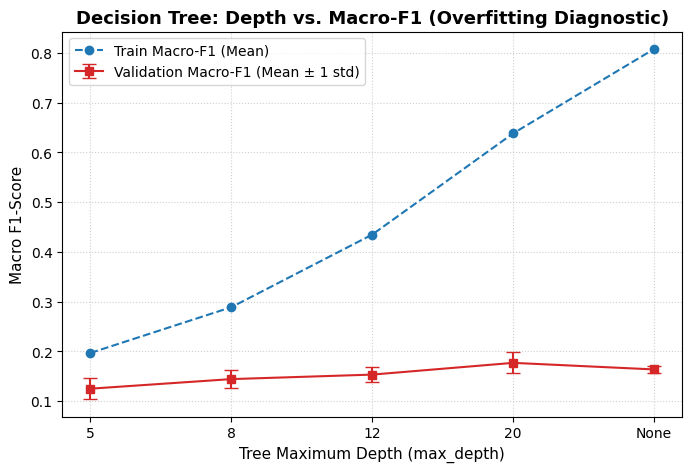

✔ Overfitting diagnostic plot saved to: results/phase2/dt_depth_vs_macro_f1.png


In [14]:
depth_values = [5, 8, 12, 20, None]
depth_labels = [str(d) for d in depth_values]

best_train_scores = []
best_val_scores = []
best_val_stds = []

for d in depth_values:
    if d is None:
        sub = dt_results[dt_results["max_depth"].isna()]
    else:
        sub = dt_results[dt_results["max_depth"] == d]
    best_row = sub.sort_values(by="mean_test_macro_f1", ascending=False).iloc[0]
    best_train_scores.append(best_row["mean_train_macro_f1"])
    best_val_scores.append(best_row["mean_test_macro_f1"])
    best_val_stds.append(best_row["std_test_macro_f1"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_labels, best_train_scores, marker="o", linestyle="--", color="#1f77b4", label="Train Macro-F1 (Mean)")
ax.errorbar(depth_labels, best_val_scores, yerr=best_val_stds, marker="s", color="#d62728", capsize=5, label="Validation Macro-F1 (Mean ± 1 std)")

ax.set_title("Decision Tree: Depth vs. Macro-F1 (Overfitting Diagnostic)", fontsize=13, fontweight="bold")
ax.set_xlabel("Tree Maximum Depth (max_depth)", fontsize=11)
ax.set_ylabel("Macro F1-Score", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="best", frameon=True)

plot_path = PHASE2_DIR / "dt_depth_vs_macro_f1.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Overfitting diagnostic plot saved to: {rel(plot_path)}")


### 3.5 Export Decision Tree Tuning Results
Store top parameters and performance statistics in `TUNING['decision_tree']`, export complete cross-validation results to CSV, and persist the best configuration as JSON.

In [15]:
import json

best_idx = dt_search.best_index_
TUNING["decision_tree"] = {
    "best_params": {k: (v if v is not None else None) for k, v in dt_search.best_params_.items()},
    "best_cv_macro_f1_mean": float(dt_results.loc[best_idx, "mean_test_macro_f1"]),
    "best_cv_macro_f1_std": float(dt_results.loc[best_idx, "std_test_macro_f1"]),
    "best_cv_accuracy_mean": float(dt_results.loc[best_idx, "mean_test_accuracy"]),
    "elapsed_seconds": float(dt_elapsed),
}

dt_results_path = PHASE2_DIR / "dt_cv_results.csv"
dt_params_path = PHASE2_DIR / "dt_best_params.json"

dt_results.to_csv(dt_results_path, index=False)

def _sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {k: _sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [_sanitize_for_json(v) for v in obj]
    elif hasattr(obj, "item"):
        return obj.item()
    return obj

with open(dt_params_path, "w", encoding="utf-8") as f:
    json.dump(_sanitize_for_json(TUNING["decision_tree"]), f, indent=2)

print("=== Decision Tree Artifacts Exported ===")
print(f"• CV Results Table : {rel(dt_results_path)} ({len(dt_results)} rows)")
print(f"• Best Config JSON : {rel(dt_params_path)}")
print(json.dumps(_sanitize_for_json(TUNING["decision_tree"]), indent=2))


=== Decision Tree Artifacts Exported ===
• CV Results Table : results/phase2/dt_cv_results.csv (30 rows)
• Best Config JSON : results/phase2/dt_best_params.json
{
  "best_params": {
    "clf__class_weight": "balanced",
    "clf__max_depth": 20,
    "clf__min_samples_leaf": 5
  },
  "best_cv_macro_f1_mean": 0.17667406916145204,
  "best_cv_macro_f1_std": 0.021074434521219255,
  "best_cv_accuracy_mean": 0.28620656021082846,
  "elapsed_seconds": 629.7789309024811
}


## 4. Random Forest Hyperparameter Tuning
### 4.1 Random Forest Randomized Grid Search
Evaluate 15 randomized configurations across tree depth, leaf constraints, feature subset ratios (`sqrt`, `log2`), and class re-weighting (`balanced_subsample`, `None`). The search enforces 5-fold grouped stratified CV with pipeline caching. `n_jobs=1` is specified for search parallelization because the forest estimator internally parallelizes across all CPU cores (`n_jobs=-1`).

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "clf__max_depth": [8, 12, 16, None],
    "clf__min_samples_leaf": [1, 3, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": ["balanced_subsample", None],
}

rf_search = RandomizedSearchCV(
    estimator=make_pipeline(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    param_distributions=param_distributions,
    n_iter=15,
    scoring=SCORING,
    refit="macro_f1",
    cv=cv_splits,
    n_jobs=1,
    random_state=RANDOM_STATE,
    return_train_score=True,
    error_score="raise",
)

print(f"Starting Random Forest RandomizedSearchCV (15 configurations x {N_SPLITS} folds = 75 fits)...")
t_start_rf = time.time()
rf_search.fit(X_train, y_train)
rf_elapsed = time.time() - t_start_rf

print(f"✔ Random Forest RandomizedSearchCV completed in {rf_elapsed:.1f}s ({rf_elapsed / 60:.2f} mins).")
print(f"Best CV Macro-F1 Score : {rf_search.best_score_:.4f}")
print(f"Best Parameters        : {rf_search.best_params_}")


Starting Random Forest RandomizedSearchCV (15 configurations x 5 folds = 75 fits)...


✔ Random Forest RandomizedSearchCV completed in 313.3s (5.22 mins).
Best CV Macro-F1 Score : 0.1708
Best Parameters        : {'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 16, 'clf__class_weight': 'balanced_subsample'}


### 4.2 Random Forest Results Analysis
Tabulate all 15 evaluated Random Forest configurations sorted by validation Macro-F1, compute generalization gap, format unweighted runs as 'None', and determine how many top configurations fall within one standard deviation of the optimum.

In [17]:
rf_results = pd.DataFrame(rf_search.cv_results_)

# Extract parameter columns and compute generalization gap
rf_results["max_depth"] = rf_results["param_clf__max_depth"]
rf_results["min_samples_leaf"] = rf_results["param_clf__min_samples_leaf"]
rf_results["max_features"] = rf_results["param_clf__max_features"]
rf_results["class_weight"] = rf_results["param_clf__class_weight"]
rf_results["gap"] = rf_results["mean_train_macro_f1"] - rf_results["mean_test_macro_f1"]

rf_display_cols = [
    "max_depth",
    "min_samples_leaf",
    "max_features",
    "class_weight",
    "mean_test_macro_f1",
    "std_test_macro_f1",
    "mean_train_macro_f1",
    "gap",
    "mean_test_accuracy",
]

rf_sorted = rf_results.sort_values(by="mean_test_macro_f1", ascending=False)[rf_display_cols].copy()
# Format class_weight None as string 'None'
rf_sorted["class_weight"] = rf_sorted["class_weight"].apply(lambda x: "None" if pd.isna(x) or x is None else str(x))

print("=== 15 Sampled Random Forest Configurations (Sorted by Validation Macro-F1) ===")
print(rf_sorted.to_string(index=False))

# Count top 5 configurations within 1 standard deviation of the best
best_rf_score = rf_search.best_score_
best_rf_std = rf_results.loc[rf_search.best_index_, "std_test_macro_f1"]
top5_rf = rf_results.sort_values(by="mean_test_macro_f1", ascending=False).head(5)
rf_within_1std = int((top5_rf["mean_test_macro_f1"] >= (best_rf_score - best_rf_std)).sum())

print(f"\nStatistical Significance Check:")
print(f"  Best Validation Macro-F1 : {best_rf_score:.4f} ± {best_rf_std:.4f}")
print(f"  1-Std Threshold Bound    : {(best_rf_score - best_rf_std):.4f}")
print(f"  Configurations in Top 5 within 1-std of Best: {rf_within_1std} / 5")


=== 15 Sampled Random Forest Configurations (Sorted by Validation Macro-F1) ===
max_depth  min_samples_leaf max_features       class_weight  mean_test_macro_f1  std_test_macro_f1  mean_train_macro_f1          gap  mean_test_accuracy
       16                 1         sqrt balanced_subsample            0.170778           0.013758             0.785850 6.150723e-01            0.259429
       12                 1         log2 balanced_subsample            0.169784           0.009288             0.763499 5.937153e-01            0.238321
     None                 3         sqrt balanced_subsample            0.165288           0.009591             0.986089 8.208017e-01            0.334550
       12                 3         log2 balanced_subsample            0.164058           0.011821             0.551013 3.869555e-01            0.206425
        8                 3         log2 balanced_subsample            0.161199           0.014738             0.485929 3.247305e-01            0.199519
  

### 4.3 Fair Comparison: Decision Tree vs. Random Forest vs. Chance Baselines
Compare the cross-validation performance of the optimal Decision Tree against the optimal Random Forest and the stratified random baseline. Statistically evaluate whether the ensemble improvement exceeds estimation variance.

In [18]:
dt_tuning = TUNING["decision_tree"]

comparison_rows = [
    {
        "Model": "Best Decision Tree",
        "CV Macro-F1 (Mean ± Std)": f"{dt_tuning['best_cv_macro_f1_mean']:.4f} ± {dt_tuning['best_cv_macro_f1_std']:.4f}",
        "CV Accuracy (Mean)": f"{dt_tuning['best_cv_accuracy_mean']:.4f}",
    },
    {
        "Model": "Best Random Forest",
        "CV Macro-F1 (Mean ± Std)": f"{best_rf_score:.4f} ± {best_rf_std:.4f}",
        "CV Accuracy (Mean)": f"{rf_results.loc[rf_search.best_index_, 'mean_test_accuracy']:.4f}",
    },
    {
        "Model": "Stratified Random Baseline",
        "CV Macro-F1 (Mean ± Std)": f"{BASELINE['stratified_random']['macro_f1_mean']:.4f} ± {BASELINE['stratified_random']['macro_f1_std']:.4f}",
        "CV Accuracy (Mean)": f"{BASELINE['stratified_random']['accuracy_mean']:.4f}",
    },
]

df_comparison = pd.DataFrame(comparison_rows)
print("=== Cross-Validation Performance Comparison ===")
print(df_comparison.to_string(index=False))

# Computed statistical comparison sentence
dt_f1_mean = dt_tuning["best_cv_macro_f1_mean"]
dt_f1_std = dt_tuning["best_cv_macro_f1_std"]
rf_f1_mean = best_rf_score
rf_f1_std = best_rf_std

diff = rf_f1_mean - dt_f1_mean
max_std = max(dt_f1_std, rf_f1_std)

if diff > max_std:
    outcome_str = "Random Forest is clearly better than the Decision Tree"
    comp_detail = f"greater than the larger standard deviation ({max_std:.4f})"
elif diff < -max_std:
    outcome_str = "Decision Tree is clearly better than the Random Forest"
    comp_detail = f"greater than the larger standard deviation ({max_std:.4f})"
else:
    outcome_str = "The Random Forest and the Decision Tree are not clearly different"
    comp_detail = f"within the larger standard deviation ({max_std:.4f})"

comp_sentence = (
    f"{outcome_str} (RF: {rf_f1_mean:.4f} ± {rf_f1_std:.4f} vs. "
    f"DT: {dt_f1_mean:.4f} ± {dt_f1_std:.4f}) because the difference ({diff:+.4f}) is {comp_detail}."
)

print(f"\n{comp_sentence}")


=== Cross-Validation Performance Comparison ===
                     Model CV Macro-F1 (Mean ± Std) CV Accuracy (Mean)
        Best Decision Tree          0.1767 ± 0.0211             0.2862
        Best Random Forest          0.1708 ± 0.0138             0.2594
Stratified Random Baseline          0.1427 ± 0.0062             0.2378

The Random Forest and the Decision Tree are not clearly different (RF: 0.1708 ± 0.0138 vs. DT: 0.1767 ± 0.0211) because the difference (-0.0059) is within the larger standard deviation (0.0211).


### 4.4 Save and Store Random Forest Results
Persist the full Random Forest CV results to CSV and save the best hyperparameter configuration as JSON in `results/phase2/`. Keep `rf_search` in memory without writing the refit model artifact to disk.

In [19]:
best_rf_idx = rf_search.best_index_
TUNING["random_forest"] = {
    "best_params": {k: (v if v is not None else None) for k, v in rf_search.best_params_.items()},
    "best_cv_macro_f1_mean": float(rf_results.loc[best_rf_idx, "mean_test_macro_f1"]),
    "best_cv_macro_f1_std": float(rf_results.loc[best_rf_idx, "std_test_macro_f1"]),
    "best_cv_accuracy_mean": float(rf_results.loc[best_rf_idx, "mean_test_accuracy"]),
    "elapsed_seconds": float(rf_elapsed),
}

rf_results_path = PHASE2_DIR / "rf_cv_results.csv"
rf_params_path = PHASE2_DIR / "rf_best_params.json"

rf_results.to_csv(rf_results_path, index=False)

def _sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {k: _sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [_sanitize_for_json(v) for v in obj]
    elif hasattr(obj, "item"):
        return obj.item()
    return obj

with open(rf_params_path, "w", encoding="utf-8") as f:
    json.dump(_sanitize_for_json(TUNING["random_forest"]), f, indent=2)

print("=== Random Forest Artifacts Exported ===")
print(f"• CV Results Table : {rel(rf_results_path)} ({len(rf_results)} rows)")
print(f"• Best Config JSON : {rel(rf_params_path)}")
print(json.dumps(_sanitize_for_json(TUNING["random_forest"]), indent=2))


=== Random Forest Artifacts Exported ===
• CV Results Table : results/phase2/rf_cv_results.csv (15 rows)
• Best Config JSON : results/phase2/rf_best_params.json
{
  "best_params": {
    "clf__min_samples_leaf": 1,
    "clf__max_features": "sqrt",
    "clf__max_depth": 16,
    "clf__class_weight": "balanced_subsample"
  },
  "best_cv_macro_f1_mean": 0.17077800575854926,
  "best_cv_macro_f1_std": 0.013757958311491588,
  "best_cv_accuracy_mean": 0.2594285908675329,
  "elapsed_seconds": 313.2736167907715
}


### 4.5 Pipeline Cache Cleanup
Remove the temporary disk directory utilized by `joblib.Memory` for pipeline caching.

In [20]:
import shutil

# Remove temporary pipeline cache directory
shutil.rmtree(CACHE_DIR, ignore_errors=True)
print(f"✔ Temporary pipeline cache directory removed: {rel(CACHE_DIR)}")


✔ Temporary pipeline cache directory removed: sk_cache_2f_ubrt1
